In [456]:
import json
import uuid
import base64
import qrcode
import base58
from typing import Optional, List
import requests
import os
from didcomm.secrets.secrets_resolver import SecretsResolver
from IPython import display
from typing import Union
from typing import Dict
from didcomm.secrets.secrets_resolver import Secret
from typing import Optional, List
from didcomm.message import Message
from didcomm.unpack import unpack, UnpackResult
from didcomm.pack_encrypted import pack_encrypted, PackEncryptedConfig
from didcomm.common.types import DID, VerificationMethodType, VerificationMaterial, VerificationMaterialFormat
from didcomm.did_doc.did_doc import DIDDoc, VerificationMethod, DIDCommService
from didcomm.common.resolvers import ResolversConfig
from didcomm.did_doc.did_resolver import DIDResolver
from peerdid.core.did_doc_types import DIDCommServicePeerDID
from peerdid import peer_did
from peerdid.types import (
    VerificationMaterialAuthentication,
    VerificationMethodTypeAuthentication,
    VerificationMaterialAgreement,
    VerificationMethodTypeAgreement,
    VerificationMaterialFormatPeerDID,
)
from didcomm.secrets.secrets_util import (
    generate_x25519_keys_as_jwk_dict,
    generate_ed25519_keys_as_jwk_dict,
)


In [486]:
class DIDResolverPeerDID(DIDResolver):
    def __init__(self, peer_did_resolver_profile="default"):
        self.peer_did_resolver_profile = peer_did_resolver_profile

    async def resolve(self, did: DID) -> DIDDoc:
        """Resolves a PeerDID into a DIDDoc with formatted services and key IDs."""
        if not did or not isinstance(did, str):
            raise ValueError("Invalid DID: DID must be a non-empty string")

        try:
            # Use custom logic to resolve the DID
            did_doc = self._resolve_did_custom(did)

            # Extract key agreement and authentication key IDs
            key_agreement_kids = did_doc.get("keyAgreement", [])
            authentication_kids = did_doc.get("authentication", [])

            # Extract DIDComm services
            didcomm_services = []
            for s in did_doc.get("service", []):
                try:
                    if isinstance(s.get("serviceEndpoint"), str):
                        service_endpoint = s["serviceEndpoint"]
                        routing_keys = []
                        accept = ["didcomm/v2"]
                    elif isinstance(s.get("serviceEndpoint"), dict):
                        service_endpoint = s["serviceEndpoint"].get("uri", "")
                        routing_keys = s["serviceEndpoint"].get("routingKeys", [])
                        accept = s["serviceEndpoint"].get("accept", ["didcomm/v2"])

                    didcomm_services.append(
                        DIDCommService(
                            id=s["id"],
                            routing_keys=routing_keys,
                            accept=accept,
                            service_endpoint=service_endpoint,
                        )
                    )
                except KeyError as e:
                    raise ValueError(f"Missing required key in service object: {e}")
                
            # Construct the DID document with appropriate key types
            verification_methods = []
            for vm in did_doc["verificationMethod"]:
                key_id = vm["id"]
                public_key_multibase = vm["publicKeyMultibase"]
                # Determine key type based on usage
                if key_id in authentication_kids:
                    key_type = "Ed25519"
                elif key_id in key_agreement_kids:
                    key_type = "X25519"
                else:
                    raise ValueError(f"Unknown key usage for key ID: {key_id}")

                # Create the VerificationMaterial object
                verification_material = VerificationMaterial(
                    format=VerificationMaterialFormat.JWK,
                    value=json.dumps({
                        "kty": "OKP",
                        "crv": key_type,
                        "x": self._ensure_valid_key(public_key_multibase, key_type),
                    }),
                )

                verification_methods.append(
                    VerificationMethod(
                        id=key_id,
                        type=VerificationMethodType.JSON_WEB_KEY_2020,
                        controller=vm["controller"],
                        verification_material=verification_material,
                    )
                )

            did_doc_obj = DIDDoc(
                did=did_doc["id"],
                verification_methods=verification_methods,
                key_agreement_kids=key_agreement_kids,
                authentication_kids=authentication_kids,
                didcomm_services=didcomm_services,  # Pass the services here
            )

            return did_doc_obj
        except Exception as e:
            raise ValueError(f"Failed to resolve DID {did}: {str(e)}")
        
    def _ensure_valid_key(self, x: str, key_type: str) -> str:
        """
        Ensures that the public key (`x` value) is a valid Ed25519 or X25519 key.
        Decodes the Base58 string (with 'z' prefix) and extracts the 32-byte key.
        """
        if not x.startswith("z"):
            raise ValueError("Invalid multibase prefix: must start with 'z'")

        # Decode Base58 (removing 'z' prefix)
        public_bytes = base58.b58decode(x[1:])
        # print(f"Decoded Key Length: {len(public_bytes)}")
        # print(f"Decoded Key: {public_bytes.hex()}")

        # Handle raw Ed25519 keys with 'ed01' prefix
        if public_bytes.startswith(b"\xed\x01"):
            if key_type != "Ed25519":
                raise ValueError(f"Invalid key type for 'ed01' prefix: expected Ed25519, got {key_type}")
            key_bytes = public_bytes[2:]  # Skip the 'ed01' prefix
            if len(key_bytes) != 32:
                raise ValueError(f"Invalid Ed25519 public key length: {len(key_bytes)} bytes")
            return base64.urlsafe_b64encode(key_bytes).decode("utf-8").rstrip("=")

        # Handle raw X25519 keys with 'ec01' prefix
        if public_bytes.startswith(b"\xec\x01"):
            if key_type != "X25519":
                raise ValueError(f"Invalid key type for 'ec01' prefix: expected X25519, got {key_type}")
            key_bytes = public_bytes[2:]  # Skip the 'ec01' prefix
            if len(key_bytes) != 32:
                raise ValueError(f"Invalid X25519 public key length: {len(key_bytes)} bytes")
            return base64.urlsafe_b64encode(key_bytes).decode("utf-8").rstrip("=")

        # Check for multicodec prefix and extract the 32-byte key
        if len(public_bytes) < 2:  # At least 2 bytes for the prefix
            raise ValueError(f"Invalid encoded key length: {len(public_bytes)} bytes")

        # Extract the prefix
        prefix = public_bytes[:2]
        key_bytes = public_bytes[2:]  # Skip the 2-byte prefix

        # Validate the prefix and key length based on the key type
        if key_type == "Ed25519":
            if prefix != b"\x12\x00":  # Ed25519 multicodec prefix
                raise ValueError(f"Invalid multicodec prefix for Ed25519 key: {prefix.hex()}")
        elif key_type == "X25519":
            if prefix != b"\x13\x00":  # X25519 multicodec prefix
                raise ValueError(f"Invalid multicodec prefix for X25519 key: {prefix.hex()}")
        else:
            raise ValueError(f"Unsupported key type: {key_type}")

        if len(key_bytes) != 32:
            raise ValueError(f"Invalid {key_type} public key length: {len(key_bytes)} bytes")

        # Re-encode the key in Base64 URL-safe format for JWK
        return base64.urlsafe_b64encode(key_bytes).decode("utf-8").rstrip("=")
    
    def _resolve_did_custom(self, did: str) -> Dict:
        """
        Custom method to resolve a Peer DID into a DID document (DIDDoc).
        """
        if not did.startswith("did:peer:"):
            raise ValueError(f"Invalid Peer DID: {did}")

        parts = did.split(":")
        if len(parts) < 3:
            raise ValueError(f"Invalid Peer DID format: {did}")

        method = parts[1]
        method_specific_id = ":".join(parts[2:])

        did_doc = {
            "@context": [
                "https://www.w3.org/ns/did/v1",
                "https://w3id.org/security/multikey/v1",
            ],
            "id": did,
            "verificationMethod": [],
            "keyAgreement": [],
            "authentication": [],  # Initialize with empty list
            "assertionMethod": [],
            "service": []  # Initialize with empty list
        }

        if method_specific_id.startswith("0"):
            return self._resolve_numalgo_0(did, method_specific_id)
        elif method_specific_id.startswith("2"):
            return self._resolve_numalgo_2(did, method_specific_id, did_doc)
        else:
            raise ValueError(f"Unsupported Peer DID algorithm: {method_specific_id}")

    def _resolve_numalgo_0(self, did: str, method_specific_id: str) -> Dict:
        """Resolves a Peer DID using numalgo 0 (inception key only)."""
        public_key_multibase = method_specific_id[1:]
        key_id = f"{did}#key-1"

        return {
            "@context": [
                "https://www.w3.org/ns/did/v1",
                "https://w3id.org/security/multikey/v1",
            ],
            "id": did,
            "verificationMethod": [{
                "id": key_id,
                "type": "Multikey",
                "controller": did,
                "publicKeyMultibase": public_key_multibase,
            }],
            "keyAgreement": [key_id],
            "authentication": [key_id],
            "assertionMethod": [key_id],
            "service": []
        }

    def _resolve_numalgo_2(self, did: str, method_specific_id: str, did_doc: Dict) -> Dict:
        parts = method_specific_id.split(".")
        verification_methods = []
        services = []

        for part in parts:
            if part.startswith(("E", "V", "A")):
                key_type = part[0]
                key_value = part[1:]
                key_id = f"{did}#key-{len(verification_methods) + 1}"

                verification_methods.append({
                    "id": key_id,
                    "type": "Multikey",
                    "controller": did,
                    "publicKeyMultibase": key_value,
                })

                if key_type == "V":
                    did_doc["authentication"].append(key_id)
                elif key_type == "A":
                    did_doc["assertionMethod"].append(key_id)
                elif key_type == "E":
                    did_doc["keyAgreement"].append(key_id)

            elif part.startswith("S"):
                try:
                    decoded_data = base64.urlsafe_b64decode(part[1:] + "===").decode("utf-8")
                    service_data = json.loads(decoded_data)
                    
                    # Ensure the service data has the correct structure
                    if "id" in service_data and "serviceEndpoint" in service_data and "type" in service_data:
                        service_endpoint = service_data["serviceEndpoint"]
                        if isinstance(service_endpoint, str):
                            service_endpoint = {"uri": service_endpoint, "routingKeys": [], "accept": ["didcomm/v2"]}
                        elif isinstance(service_endpoint, dict):
                            if "uri" not in service_endpoint:
                                service_endpoint["uri"] = ""
                            if "routingKeys" not in service_endpoint:
                                service_endpoint["routingKeys"] = []
                            if "accept" not in service_endpoint:
                                service_endpoint["accept"] = ["didcomm/v2"]
                        
                        services.append({
                            "id": service_data["id"],
                            "type": service_data["type"],
                            "serviceEndpoint": service_endpoint,
                        })
                except (base64.binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as e:
                    print(f"Failed to decode or parse service data in {part}: {e}")

        did_doc["verificationMethod"].extend(verification_methods)
        did_doc["service"].extend(services)

        return did_doc

In [487]:
def jwk_to_secret(jwk_dict: dict) -> Secret:
    """Convert a JWK dictionary to a Secret object."""
    return Secret(
        kid=jwk_dict.get("kid"),
        type=VerificationMethodType.JSON_WEB_KEY_2020,
        verification_material=VerificationMaterial(
            format=VerificationMaterialFormat.JWK,
            value=json.dumps(jwk_dict),
    ))

In [505]:

class LocalSecretsResolver(SecretsResolver):
    def __init__(self, storage_file: str = 'secrets.json'):
        self.storage_file = storage_file
        self.load_secrets()

    def load_secrets(self):
        """Load secrets from the JSON file."""
        if os.path.exists(self.storage_file):
            with open(self.storage_file, 'r') as f:
                # Load secrets as a list
                secrets_list = json.load(f)
                # Convert list to dict
                self.secrets = {secret['kid']: secret for secret in secrets_list}
        else:
            self.secrets = {}
            print("No secrets file found, initialized as empty dictionary.")

    def save_secrets(self):
        """Save secrets to the JSON file."""
        with open(self.storage_file, 'w') as f:
            json.dump(list(self.secrets.values()), f, indent=4)  # Save as a list

    async def add_key(self, secret: dict):
        """Add a secret to the local storage."""
        kid = secret.get("kid")
        if not kid:
            raise ValueError("Secret must have a 'kid' (key ID).")

        # Ensure the secret has the correct JWK format
        if "verification_material" not in secret:
            raise ValueError("Secret must have a 'verification_material' field.")
        if "value" not in secret["verification_material"]:
            raise ValueError("Secret's verification_material must have a 'value' field.")
        if "kty" not in secret["verification_material"]["value"]:
            raise ValueError("Secret's verification_material value must have a 'kty' field.")

        self.secrets[kid] = secret
        self.save_secrets()

    async def get_key(self, kid: str) -> Optional[Secret]:
        """Retrieve a secret by its key ID and convert it to a Secret object."""
        secret_dict = self.secrets.get(kid)
        if secret_dict:
            # Ensure verification_material.value is a dictionary
            if isinstance(secret_dict["verification_material"]["value"], str):
                try:
                    secret_dict["verification_material"]["value"] = json.loads(
                        secret_dict["verification_material"]["value"]
                    )
                except json.JSONDecodeError as e:
                    raise ValueError(f"Invalid JSON in verification_material.value: {e}")

            # Convert the dictionary to a Secret object
            secret_object = jwk_to_secret(secret_dict["verification_material"]["value"])
            return secret_object
        else:
            return None

    async def delete_key(self, kid: str):
        """Delete a secret by its key ID."""
        if kid in self.secrets:
            del self.secrets[kid]
            self.save_secrets()

    async def get_keys(self, filter: Optional[Union[dict, list]] = None) -> list:
        """
        Retrieve all keys stored in the local storage.
        If `filter` is a list, return keys with matching KIDs.
        If `filter` is a dict, return keys that match the filter criteria.
        If `filter` is None, return all keys.
        """
        if filter is None:
            return list(self.secrets.values())
        
        if isinstance(filter, list):
            # Handle case where filter is a list of key IDs (KIDs)
            filtered_keys = []
            for kid in filter:
                if kid in self.secrets:
                    filtered_keys.append(self.secrets[kid])
            return filtered_keys
        elif isinstance(filter, dict):
            # Handle case where filter is a dictionary for custom filtering
            filtered_keys = []
            for key in self.secrets.values():
                if all(key.get(k) == v for k, v in filter.items()):
                    filtered_keys.append(key)
            return filtered_keys
        else:
            raise TypeError(f"Invalid filter type: {type(filter)}. Expected list or dict.")
        
    async def get_kids(self) -> List[str]:
        """Retrieve all key IDs (KIDs) stored in the local storage."""
        return list(self.secrets.keys())

    async def get_public_key_bytes(self, kid: str) -> bytes:
        secret = self.secrets.get(kid)
        if secret:
            jwk = secret["verification_material"]
            x_bytes = base64.urlsafe_b64decode(jwk["x"] + "=" * (-len(jwk["x"]) % 4))
            if len(x_bytes) != 32:
                raise ValueError(f"Invalid public key length: expected 32 bytes, got {len(x_bytes)}")
            return x_bytes
        else:
            raise ValueError(f"Secret not found for kid {kid}")

In [506]:
async def create_peer_did(
    auth_keys_count: int = 1,
    agreement_keys_count: int = 1,
    service_endpoint: Optional[str] = None,
    service_routing_keys: Optional[List[str]] = None,
) -> str:
    # 1. Generate keys in JWK format
    agreem_keys = [generate_x25519_keys_as_jwk_dict() for _ in range(agreement_keys_count)]
    auth_keys = [generate_ed25519_keys_as_jwk_dict() for _ in range(auth_keys_count)]

    # 2. Prepare the keys for peer DID lib with correct multicodec prefixes
    agreem_keys_peer_did = [
        VerificationMaterialAgreement(
            type=VerificationMethodTypeAgreement.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1]["x"],  # Public key 'x' value
        )
        for k in agreem_keys
    ]
    auth_keys_peer_did = [
        VerificationMaterialAuthentication(
            type=VerificationMethodTypeAuthentication.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1]["x"],  # Public key 'x' value
        )
        for k in auth_keys
    ]

    # 3. Generate service
    service = None
    if service_endpoint:
        service_data = {
            "id": "#didcomm",
            "serviceEndpoint": {
                "uri": service_endpoint,
                "routingKeys": service_routing_keys if service_routing_keys else [],
                "accept": ["didcomm/v2"],
            },
            "type": "DIDCommMessaging",
        }
        service = json.dumps(service_data)

    # 4. Construct the method_specific_id for numalgo 2
    method_specific_id = "2"
    for key in auth_keys_peer_did:
        # Decode the JWK 'x' value (Base64 URL-safe) and prepend Ed25519 prefix (0x1200)
        key_bytes = base64.urlsafe_b64decode(key.value + "===")
        if len(key_bytes) != 32:
            raise ValueError(f"Invalid Ed25519 key length: {len(key_bytes)} bytes")
        encoded_x = b"\xed\x01" + key_bytes  # Prepend Ed25519 multicodec prefix
        method_specific_id += f".Vz{base58.b58encode(encoded_x).decode('utf-8')}"  # Add authentication key

    for key in agreem_keys_peer_did:
        # Decode the JWK 'x' value (Base64 URL-safe) and prepend X25519 prefix (0x1300)
        key_bytes = base64.urlsafe_b64decode(key.value + "===")
        if len(key_bytes) != 32:
            raise ValueError(f"Invalid X25519 key length: {len(key_bytes)} bytes")
        encoded_x = b"\xec\x01" + key_bytes  # Prepend X25519 multicodec prefix
        method_specific_id += f".Ez{base58.b58encode(encoded_x).decode('utf-8')}"  # Add agreement key

    if service:
        encoded_service = base64.urlsafe_b64encode(service.encode("utf-8")).decode("utf-8").rstrip("=")
        method_specific_id += f".S{encoded_service}"  # Add service

    did = f"did:peer:{method_specific_id}"

    # 5. Resolve the DID using your custom resolver and store secrets
    secrets_resolver = LocalSecretsResolver()
    resolver_roots = DIDResolverPeerDID()
    did_doc = resolver_roots._resolve_did_custom(did)
    did_doc_resolve = print("Resolved DID Document:", json.dumps(did_doc, indent=4))
    

    # Extract the key IDs from the resolved DID document
    auth_kids = [vm["id"] for vm in did_doc["verificationMethod"] if vm["id"] in did_doc["authentication"]]
    agreement_kids = [vm["id"] for vm in did_doc["verificationMethod"] if vm["id"] in did_doc["keyAgreement"]]

    # Store the private keys with appropriate IDs
    for idx, auth_key in enumerate(auth_keys):
        if idx < len(auth_kids):
            private_key = auth_key[0]
            private_key["kid"] = auth_kids[idx]
            secret = jwk_to_secret(private_key)
            secret_dict = {
                "kid": secret.kid,
                "type": str(secret.type),
                "verification_material": {
                    "format": secret.verification_material.format.name,
                    "value": secret.verification_material.value
                }
            }
            await secrets_resolver.add_key(secret_dict)

    for idx, agreem_key in enumerate(agreem_keys):
        if idx < len(agreement_kids):
            private_key = agreem_key[0]
            private_key["kid"] = agreement_kids[idx]
            secret = jwk_to_secret(private_key)
            secret_dict = {
                "kid": secret.kid,
                "type": str(secret.type),
                "verification_material": {
                    "format": secret.verification_material.format.name,
                    "value": secret.verification_material.value
                }
            }
            await secrets_resolver.add_key(secret_dict)

    return did

### Alice get OOB from Mediator

In [507]:
#oob_url = requests.get("http://127.0.0.1:8000/oob_url").text
oob_url = requests.get("http://localhost:8080/oob_url").text

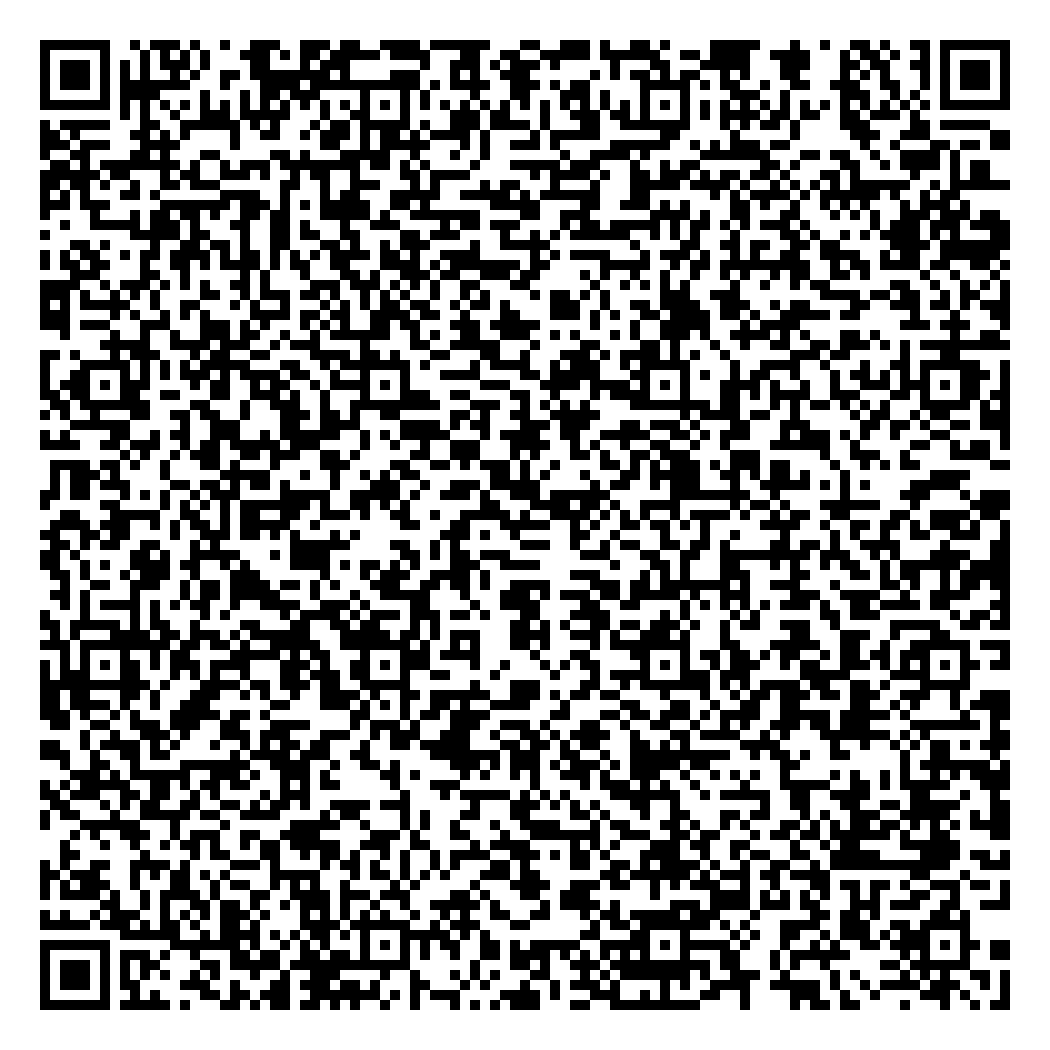

In [508]:
im = qrcode.make(oob_url)
im.save('qr.png')
display.Image('qr.png',width=500,height=500)

In [509]:
received_msg_encoded = oob_url.split("=")[1]
received_msg_decoded = json.loads(str(base64.urlsafe_b64decode(received_msg_encoded + "=="), "utf-8"))
to = received_msg_decoded["from"]
print(to)

alice_did_for_mediator = await create_peer_did(1, 1, "http://localhost:8080")
print("DID:", alice_did_for_mediator)

did:peer:2.Vz6MkhsYJHMiLfVs56keDxFXMoUVEE7rDLQkkmu6D1yKwNDsg.Ez6LSrf5VjRHYnW3i86bEhG4brfQHtSsHPbWmKE6neyxmGmhE.SeyJpZCI6IiNkaWRjb21tIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9LCJ0IjoiZG0ifQ
Resolved DID Document: {
    "@context": [
        "https://www.w3.org/ns/did/v1",
        "https://w3id.org/security/multikey/v1"
    ],
    "id": "did:peer:2.Vz6MkuMLhXWBudyrcrxfDieretaF8h6Utbr9WRE17aDBgyhqS.Ez6LSnFT9ADGTFHsXhaTPW4w4Ka84dLW8da1A8mDJbDhB37tS.SeyJpZCI6ICIjZGlkY29tbSIsICJzZXJ2aWNlRW5kcG9pbnQiOiB7InVyaSI6ICJodHRwOi8vbG9jYWxob3N0OjgwODAiLCAicm91dGluZ0tleXMiOiBbXSwgImFjY2VwdCI6IFsiZGlkY29tbS92MiJdfSwgInR5cGUiOiAiRElEQ29tbU1lc3NhZ2luZyJ9",
    "verificationMethod": [
        {
            "id": "did:peer:2.Vz6MkuMLhXWBudyrcrxfDieretaF8h6Utbr9WRE17aDBgyhqS.Ez6LSnFT9ADGTFHsXhaTPW4w4Ka84dLW8da1A8mDJbDhB37tS.SeyJpZCI6ICIjZGlkY29tbSIsICJzZXJ2aWNlRW5kcG9pbnQiOiB7InVyaSI6ICJodHRwOi8vbG9jYWxob3N0OjgwODAiLCAicm91dGluZ0tleXMiOiBbXSwgImFjY2VwdCI6IFsiZGlkY29t

### Alice request mediate

In [510]:
alice_mediate_grant = Message(
    id=str(uuid.uuid4()),
    type="https://didcomm.org/coordinate-mediation/2.0/mediate-request",
    body={},
    frm = alice_did_for_mediator,
    custom_headers=[{"return_route": "all"}]
)
print(alice_mediate_grant)

Message(id='baf476be-ec5d-4d94-bd9e-1c9fe7b879d6', type='https://didcomm.org/coordinate-mediation/2.0/mediate-request', body={}, frm='did:peer:2.Vz6MkuMLhXWBudyrcrxfDieretaF8h6Utbr9WRE17aDBgyhqS.Ez6LSnFT9ADGTFHsXhaTPW4w4Ka84dLW8da1A8mDJbDhB37tS.SeyJpZCI6ICIjZGlkY29tbSIsICJzZXJ2aWNlRW5kcG9pbnQiOiB7InVyaSI6ICJodHRwOi8vbG9jYWxob3N0OjgwODAiLCAicm91dGluZ0tleXMiOiBbXSwgImFjY2VwdCI6IFsiZGlkY29tbS92MiJdfSwgInR5cGUiOiAiRElEQ29tbU1lc3NhZ2luZyJ9', to=None, created_time=None, expires_time=None, from_prior=None, please_ack=None, ack=None, thid=None, pthid=None, attachments=None, custom_headers=[{'return_route': 'all'}])


In [511]:
alice_mediate_grant_packed = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = LocalSecretsResolver(),
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_mediate_grant,
    frm = alice_did_for_mediator,
    to = received_msg_decoded["from"],
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
print(alice_mediate_grant_packed.packed_msg)


{"protected":"eyJ0eXAiOiJhcHBsaWNhdGlvbi9kaWRjb21tLWVuY3J5cHRlZCtqc29uIiwiYWxnIjoiRUNESC0xUFUrQTI1NktXIiwiZW5jIjoiQTI1NkNCQy1IUzUxMiIsImFwdSI6IlpHbGtPbkJsWlhJNk1pNVdlalpOYTNWTlRHaFlWMEoxWkhseVkzSjRaa1JwWlhKbGRHRkdPR2cyVlhSaWNqbFhVa1V4TjJGRVFtZDVhSEZUTGtWNk5reFRia1pVT1VGRVIxUkdTSE5ZYUdGVVVGYzBkelJMWVRnMFpFeFhPR1JoTVVFNGJVUktZa1JvUWpNM2RGTXVVMlY1U25CYVEwazJTVU5KYWxwSGJHdFpNamwwWWxOSmMwbERTbnBhV0VveVlWZE9iRkpYTld0alJ6bHdZbTVSYVU5cFFqZEpibFo1WVZOSk5rbERTbTlrU0ZKM1QyazRkbUpIT1dwWlYzaHZZak5PTUU5cVozZFBSRUZwVEVOQmFXTnRPVEZrUjJ4MVdqQjBiR1ZZVFdsUGFVSmlXRk4zWjBsdFJtcFpNbFozWkVOSk5rbEdjMmxhUjJ4cldUSTVkR0pUT1RKTmFVcGtabE4zWjBsdVVqVmpSMVZwVDJsQmFWSkZiRVZSTWpsMFlsVXhiR016VG1oYU1teDFXbmxLT1NOclpYa3RNZyIsImFwdiI6Ik4zZ1VwazRuRU1NTTQxSlctX2tTYWVfbnQxbm0tUnl0Vm9aZk5YMW5OeWsiLCJza2lkIjoiZGlkOnBlZXI6Mi5WejZNa3VNTGhYV0J1ZHlyY3J4ZkRpZXJldGFGOGg2VXRicjlXUkUxN2FEQmd5aHFTLkV6NkxTbkZUOUFER1RGSHNYaGFUUFc0dzRLYTg0ZExXOGRhMUE4bURKYkRoQjM3dFMuU2V5SnBaQ0k2SUNJalpHbGtZMjl0YlNJc0lDSnpaWEoyYVdObFJXNWtjRzlwYm5RaU9pQjdJbl

### Sending to Mediator

In [512]:
mediator_did_doc = json.loads(peer_did.resolve_peer_did(received_msg_decoded["from"]))
mediator_endpoint = mediator_did_doc["service"][0]["serviceEndpoint"]["uri"]
print(mediator_endpoint)

http://localhost:8080


In [513]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, json = json.loads(alice_mediate_grant_packed.packed_msg))


In [526]:
medresp = json.dumps(resp.json(), indent=4)
print("Packed message response:", medresp)

Packed message response: {
    "protected": "eyJ0eXAiOiJhcHBsaWNhdGlvbi9kaWRjb21tLWVuY3J5cHRlZCtqc29uIiwiYWxnIjoiRUNESC0xUFUrQTI1NktXIiwiZW5jIjoiQTI1NkNCQy1IUzUxMiIsInNraWQiOiJkaWQ6cGVlcjoyLlZ6Nk1raHNZSkhNaUxmVnM1NmtlRHhGWE1vVVZFRTdyRExRa2ttdTZEMXlLd05Ec2cuRXo2TFNyZjVWalJIWW5XM2k4NmJFaEc0YnJmUUh0U3NIUGJXbUtFNm5leXhtR21oRS5TZXlKcFpDSTZJaU5rYVdSamIyMXRJaXdpY3lJNmV5SmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhTd2ljaUk2VzEwc0luVnlhU0k2SW1oMGRIQTZMeTlzYjJOaGJHaHZjM1E2T0RBNE1DSjlMQ0owSWpvaVpHMGlmUSNrZXktMiIsImFwdSI6IlpHbGtPbkJsWlhJNk1pNVdlalpOYTJoeldVcElUV2xNWmxaek5UWnJaVVI0UmxoTmIxVldSVVUzY2tSTVVXdHJiWFUyUkRGNVMzZE9SSE5uTGtWNk5reFRjbVkxVm1wU1NGbHVWek5wT0RaaVJXaEhOR0p5WmxGSWRGTnpTRkJpVjIxTFJUWnVaWGw0YlVkdGFFVXVVMlY1U25CYVEwazJTV2xPYTJGWFVtcGlNakYwU1dsM2FXTjVTVFpsZVVwb1NXcHdZa2x0VW5CYVIwNTJZbGN3ZG1ScVNXbFlVM2RwWTJsSk5sY3hNSE5KYmxaNVlWTkpOa2x0YURCa1NFRTJUSGs1YzJJeVRtaGlSMmgyWXpOUk5rOUVRVFJOUTBvNVRFTktNRWxxYjJsYVJ6QnBabEVqYTJWNUxUSSIsImFwdiI6Im9HTHhTYjJLajFvYTdjQlljdlBvNDdUNkVjRFJHdk8wU3owTDgwaUNhNHMiLCJlcGs

### Get mediator grant response

In [541]:

mediator_unpack_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=LocalSecretsResolver(),
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= json.dumps(medresp)
)
print(mediator_unpack_msg.message.type)
print("Routing Key: " + mediator_unpack_msg.message.body["routing_did"])
print("Mediator new DID: " + mediator_unpack_msg.message.from_prior.sub)
# mediator rotated did
mediator_routing_key = mediator_unpack_msg.message.body["routing_did"]
mediator_did = mediator_unpack_msg.message.from_prior.sub

MalformedMessageError: MalformedMessageCode.INVALID_PLAINTEXT

### Keylist update

Alice create a new DID to share with  other peers using mediator routing keys 

In [521]:
#alice_did_new = await create_peer_did(1, 1, service_endpoint=mediator_endpoint, service_routing_keys=[mediator_routing_key])
alice_did_for_bob = await create_peer_did(1, 1, service_endpoint=[{"uri": mediator_routing_key}])

print("Alice's DID for Bob:", alice_did_for_bob)

NameError: name 'mediator_routing_key' is not defined

Alice create and send the keylist update message

In [83]:
alice_keylist_update = Message(
    id = "unique-id-293e9a922efff",
    type = "https://didcomm.org/coordinate-mediation/2.0/keylist-update",
    body = {
        "updates":[
        {
            "recipient_did": alice_did_for_bob,
            "action": "add"
        }
    ]
    }
)

In [84]:
alice_keylist_update_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_keylist_update,
    frm = alice_did_for_mediator,
    to = mediator_did,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)

In [85]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, data = alice_keylist_update_packed_msg.packed_msg)

In [86]:
mediator_unpack_msg2 = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg2.message.type)
print(mediator_unpack_msg2.message.body)


https://didcomm.org/coordinate-mediation/2.0/keylist-update-response
{'updated': [{'recipient_did': 'did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0', 'action': 'add', 'result': 'success'}]}


### Alice can now send her DID to Bob. Copy Alice's DID into Bob's notebook, and follows Bob's notebook

In [87]:
print(alice_did_for_bob)

did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0


### Alice check status of queued messages from the Mediator

In [ ]:
alice_status_check = Message(
    id = "unique-id-293e9a922efffxxx",
    type = "https://didcomm.org/messagepickup/3.0/status-request",
    body = {}
)

In [ ]:
alice_status_check_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_status_check,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp3 = requests.post(mediator_endpoint, headers=headers, data = alice_status_check_packed_msg.packed_msg)

In [ ]:
mediator_unpack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp3.json()
)
print(mediator_unpack_status.message.type)
print("Messages in Mediator queue: " + str(mediator_unpack_status.message.body["message_count"]))

### If there are messages, Alice can pickup from the mediator (delivery request)

In [ ]:
alice_delivery_request = Message(
    id = "unique-id-293e9a922efffxxxff",
    type = "https://didcomm.org/messagepickup/3.0/delivery-request",
    body = {"limit": 1}
)

In [ ]:
alice_delivery_request_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_delivery_request,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp4 = requests.post(mediator_endpoint, headers=headers, data = alice_delivery_request_packed_msg.packed_msg)

In [ ]:
mediator_delivery = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp4.json()
)
print(mediator_delivery.message.type)
print(mediator_delivery.message.body)

In [ ]:
bob_packed_msg = mediator_delivery.message.attachments[0].data.json
msg_id = mediator_delivery.message.attachments[0].id

In [ ]:
print(bob_packed_msg)

In [ ]:
bob_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= bob_packed_msg
)

In [ ]:
print("Message ID:", msg_id)
print(bob_msg.message.body["content"])

### Alice acknowledge so the mediator can delete the message

In [ ]:
alice_ack = Message(
    id = "unique-id-293e9a922efffxxxffsss",
    type = "https://didcomm.org/messagepickup/3.0/messages-received",
    body = {"message_id_list": [msg_id]}
)

In [ ]:
alice_ack_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_ack,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp5 = requests.post(mediator_endpoint, headers=headers, data = alice_ack_packed_msg.packed_msg)

In [ ]:
mediator_ack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp5.json()
)
print(mediator_ack_status.message.type)
print(mediator_ack_status.message.body)